In [1]:
import matplotlib.pyplot as plt, numpy as np, seaborn as sns, scipy.stats as stats, pandas as pd, os, glob
import ast
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 1. preprocess old versions

In [2]:
# create concatenated df
df_old = pd.DataFrame()

for subj_file in glob.glob('../../results/psychopy/asymmetry*.csv'):
    df_subj = pd.read_csv(subj_file)[:240]
    df_old = pd.concat([df_old, df_subj], ignore_index=True)

df_old.to_csv('../../results/psychopy/all_subjs_v2.csv', index=False)
df_old

,thisN,thisTrialN,thisRepN,blockN,run,condition,trial_key,stim_file_pos,stim_pos,noise_pos,...,subj,difficulty,sess_type,date,expName,psychopyVersion,frameRate,expStart,Unnamed: 119,Unnamed: 112
0,0.0,0.0,0.0,1.0,1.0,baseline,10.0,1.1,-0.18,1.0,...,202509.0,patients,A,2025-05-23_14h44.58.284,asymmetry_final,2024.2.4,60.0,2025-05-23 14h45.10.782086 -0600,NaN,NaN
1,1.0,1.0,0.0,1.0,1.0,baseline,7.0,0.7,-0.26,1.0,...,202509.0,patients,A,2025-05-23_14h44.58.284,asymmetry_final,2024.2.4,60.0,2025-05-23 14h45.10.782086 -0600,NaN,NaN
2,2.0,2.0,0.0,1.0,1.0,baseline,37.0,3.7,0.34,3.0,...,202509.0,patients,A,2025-05-23_14h44.58.284,asymmetry_final,2024.2.4,60.0,2025-05-23 14h45.10.782086 -0600,NaN,NaN
3,3.0,3.0,0.0,1.0,1.0,baseline,14.0,1.5,-0.10,1.0,...,202509.0,patients,A,2025-05-23_14h44.58.284,asymmetry_final,2024.2.4,60.0,2025-05-23 14h45.10.782086 -0600,NaN,NaN
4,4.0,4.0,0.0,1.0,1.0,baseline,8.0,0.9,-0.22,1.0,...,202509.0,patients,A,2025-05-23_14h44.58.284,asymmetry_final,2024.2.4,60.0,2025-05-23 14h45.10.782086 -0600,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,35.0,35.0,0.0,6.0,2.0,flat_comp,236.0,3.9,0.38,1.0,...,202518.0,patients,D,2025-10-04_16h05.12.182,asymmetry_final,2024.2.4,60.0,2025-10-04 16h05.25.163659 -0600,NaN,NaN
1436,36.0,36.0,0.0,6.0,2.0,flat_comp,226.0,3.3,0.26,1.0,...,202518.0,patients,D,2025-10-04_16h05.12.182,asymmetry_final,2024.2.4,60.0,2025-10-04 16h05.25.163659 -0600,NaN,NaN
1437,37.0,37.0,0.0,6.0,2.0,flat_comp,223.0,3.1,0.22,1.0,...,202518.0,patients,D,2025-10-04_16h05.12.182,asymmetry_final,2024.2.4,60.0,2025-10-04 16h05.25.163659 -0600,NaN,NaN
1438,38.0,38.0,0.0,6.0,2.0,flat_comp,218.0,2.9,0.18,3.0,...,202518.0,patients,D,2025-10-04_16h05.12.182,asymmetry_final,2024.2.4,60.0,2025-10-04 16h05.25.163659 -0600,NaN,NaN


In [3]:
df_old['direction'] = df_old['shape_order'].map({'curv_flat': 1, 'flat_curv': -1})
df_old['true_div'] = np.where( df_old['direction'] == -1, -df_old['div_pos'], df_old['div_pos'] ) 

df_old[['shape_order', 'direction', 'true_div']].head(5)

,shape_order,direction,true_div
0,curv_flat,1,0.0
1,flat_curv,-1,-0.0
2,flat_curv,-1,-0.0
3,curv_flat,1,0.0
4,curv_flat,1,0.0


valence flipping entire sessions because we didnt counterbalance halfway

In [4]:
# Assert valence mapping for each session type
df_sessions_AC = df_old[df_old['sess_type'].isin(['A', 'C'])]
assert (df_sessions_AC[df_sessions_AC['shape'] == 'curv']['valence'] == 'pen').all()
assert (df_sessions_AC[df_sessions_AC['shape'] == 'flat']['valence'] == 'rew').all()

df_sessions_BD = df_old[df_old['sess_type'].isin(['B', 'D'])]
assert (df_sessions_BD[df_sessions_BD['shape'] == 'curv']['valence'] == 'rew').all()
assert (df_sessions_BD[df_sessions_BD['shape'] == 'flat']['valence'] == 'pen').all()

# Create valence_flipped column: 1 for A/C, -1 for B/D
df_old['valence_flipped'] = np.where(df_old['sess_type'].isin(['A', 'C']), 1, -1)

### 2. preprocess new versions

In [5]:
# create concatenated df
df_new = pd.DataFrame()

for subj_file in glob.glob('../../results/psychopy/asymmetry_v2*.csv'):
    df_subj = pd.read_csv(subj_file)[:240]
    df_new = pd.concat([df_new, df_subj], ignore_index=True)

df_new

""


### 3. combine dfs and global preprocess

In [6]:
df_subjs = pd.concat([df_old, df_new], ignore_index=True)
print(df_subjs.shape)
df_subjs.head(5)

(1440, 124)


,thisN,thisTrialN,thisRepN,blockN,run,condition,trial_key,stim_file_pos,stim_pos,noise_pos,...,date,expName,psychopyVersion,frameRate,expStart,Unnamed: 119,Unnamed: 112,direction,true_div,valence_flipped
0,0.0,0.0,0.0,1.0,1.0,baseline,10.0,1.1,-0.18,1.0,...,2025-05-23_14h44.58.284,asymmetry_final,2024.2.4,60.0,2025-05-23 14h45.10.782086 -0600,NaN,NaN,1,0.0,1
1,1.0,1.0,0.0,1.0,1.0,baseline,7.0,0.7,-0.26,1.0,...,2025-05-23_14h44.58.284,asymmetry_final,2024.2.4,60.0,2025-05-23 14h45.10.782086 -0600,NaN,NaN,-1,-0.0,1
2,2.0,2.0,0.0,1.0,1.0,baseline,37.0,3.7,0.34,3.0,...,2025-05-23_14h44.58.284,asymmetry_final,2024.2.4,60.0,2025-05-23 14h45.10.782086 -0600,NaN,NaN,-1,-0.0,1
3,3.0,3.0,0.0,1.0,1.0,baseline,14.0,1.5,-0.10,1.0,...,2025-05-23_14h44.58.284,asymmetry_final,2024.2.4,60.0,2025-05-23 14h45.10.782086 -0600,NaN,NaN,1,0.0,1
4,4.0,4.0,0.0,1.0,1.0,baseline,8.0,0.9,-0.22,1.0,...,2025-05-23_14h44.58.284,asymmetry_final,2024.2.4,60.0,2025-05-23 14h45.10.782086 -0600,NaN,NaN,1,0.0,1


In [7]:
# convert string to list, and store target_resp
for column in ['positions']:
    if type(df_subjs[column][0]) == str:
        df_subjs.loc[:, column] = df_subjs[column].apply(ast.literal_eval)       
df_subjs['target_resp'] = df_subjs['positions'].apply(lambda x: x[-1])

# true_resp column flips target_resp when direction = -1 (flat_curv)
df_subjs['true_resp'] = np.where( df_subjs['direction'] == -1, -df_subjs['target_resp'], df_subjs['target_resp'] ) 

df_subjs[['shape_order', 'direction', 'target_resp', 'true_resp']].head(5)

,shape_order,direction,target_resp,true_resp
0,curv_flat,1,0.064,0.064
1,flat_curv,-1,0.100,-0.100
2,flat_curv,-1,-0.136,0.136
3,curv_flat,1,-0.136,-0.136
4,curv_flat,1,0.056,0.056


In [8]:
# rename certain columns
df_subjs = df_subjs.rename(columns={'stim_pos':'true_stim', 'target_pos':'target_stim', 
                                    'true_div':'true_boundary', 'div_pos':'target_boundary',
                                    'true_resp':'true_resp', 'target_resp':'target_resp'})

df_subjs[['condition',
          'true_stim', 'target_stim',
          'true_boundary', 'target_boundary',
          'true_resp', 'target_resp']].head(5)


,condition,true_stim,target_stim,true_boundary,target_boundary,true_resp,target_resp
0,baseline,-0.18,-0.18,0.0,0.0,0.064,0.064
1,baseline,-0.26,0.26,-0.0,0.0,-0.100,0.100
2,baseline,0.34,-0.34,-0.0,0.0,0.136,-0.136
3,baseline,-0.10,-0.10,0.0,0.0,-0.136,-0.136
4,baseline,-0.22,-0.22,0.0,0.0,0.056,0.056


Important: flip positions based on valence
* when curvy = loss (& flat = gain), all is fine
* when curvy = gain (& flat = loss), need to flip positions

In [9]:
# find indices and flip
df_subjs['valence_flipped'] = (
    ((df_subjs['shape'] == 'curv') & (df_subjs['valence'] == 'rew')) |
    ((df_subjs['shape'] == 'flat') & (df_subjs['valence'] == 'pen'))
)

# reminder that below wont be true because of older version files
# assert (df_subjs['valence_flipped'] == (df_subjs['blockN'] >= 4)).all()

df_subjs['valence_stim'] = np.where(df_subjs['valence_flipped'], -df_subjs['true_stim'], df_subjs['true_stim'])
df_subjs['valence_boundary'] = np.where(df_subjs['valence_flipped'], -df_subjs['true_boundary'], df_subjs['true_boundary'])
df_subjs['valence_resp'] = np.where(df_subjs['valence_flipped'], -df_subjs['true_resp'], df_subjs['true_resp'])

df_subjs[['blockN', 'shape', 'valence',
          'true_stim', 'valence_stim',
          'true_boundary', 'valence_boundary',
          'true_resp', 'valence_resp']].head(5)

,blockN,shape,valence,true_stim,valence_stim,true_boundary,valence_boundary,true_resp,valence_resp
0,1.0,curv,pen,-0.18,-0.18,0.0,0.0,0.064,0.064
1,1.0,curv,pen,-0.26,-0.26,-0.0,-0.0,-0.100,-0.100
2,1.0,flat,rew,0.34,0.34,-0.0,-0.0,0.136,0.136
3,1.0,curv,pen,-0.10,-0.10,0.0,0.0,-0.136,-0.136
4,1.0,curv,pen,-0.22,-0.22,0.0,0.0,0.056,0.056


In [26]:
# error trials
df_subjs['invalid'] = df_subjs['trials.slider_resp.rt'].isna()
df_subjs['incomplete'] = df_subjs['trials.submit_resp.keys'].isna()
df_subjs['incorrect'] = (df_subjs['correct']==0) & ~df_subjs['invalid'] & ~df_subjs['incomplete']

print(f"invalid: {df_subjs['invalid'].mean()*100:.1f}%")
print(f"incomplete: {df_subjs['incomplete'].mean()*100:.1f}%")
print(f"incorrect: {df_subjs['incorrect'].mean()*100:.1f}%")
df_subjs[['correct', 'invalid', 'incomplete', 'incorrect']].head(5)

invalid: 2.1%
incomplete: 2.5%
incorrect: 17.2%


,correct,invalid,incomplete,incorrect
0,1.0,False,False,False
1,1.0,False,False,False
2,1.0,False,False,False
3,1.0,False,False,False
4,1.0,False,False,False


In [11]:
# boundary alignment
df_subjs['stim_boundary_aligned'] = (df_subjs['true_stim'] - df_subjs['true_boundary']).round(3)
df_subjs['resp_boundary_aligned'] = (df_subjs['true_resp'] - df_subjs['true_boundary']).round(3)

df_subjs[['true_stim', 'true_boundary', 'stim_boundary_aligned', 'true_resp', 'resp_boundary_aligned']].tail(5)

,true_stim,true_boundary,stim_boundary_aligned,true_resp,resp_boundary_aligned
1435,0.38,0.2,0.18,0.236,0.036
1436,0.26,0.2,0.06,0.240,0.040
1437,0.22,0.2,0.02,0.220,0.020
1438,0.18,0.2,-0.02,0.256,0.056
1439,0.38,0.2,0.18,0.204,0.004


In [18]:
# ranking positions within subj/condition, averaged across 2 blocks
grp = ['subj', 'condition']#, 'blockN']
df_subjs = df_subjs.assign(
                            rank_stim = df_subjs.groupby(grp)['true_stim'].transform('rank'),
                            rank_resp = df_subjs.groupby(grp)['true_resp'].transform('rank'),
                          ).copy()
df_subjs[['subj', 'condition', 'true_stim', 'rank_stim', 'true_resp', 'rank_resp']].head(5)

,subj,condition,true_stim,rank_stim,true_resp,rank_resp
0,202509.0,baseline,-0.18,22.5,0.064,61.5
1,202509.0,baseline,-0.26,14.5,-0.100,8.0
2,202509.0,baseline,0.34,74.5,0.136,75.5
3,202509.0,baseline,-0.10,30.5,-0.136,5.0
4,202509.0,baseline,-0.22,18.5,0.056,60.0


### timing checks

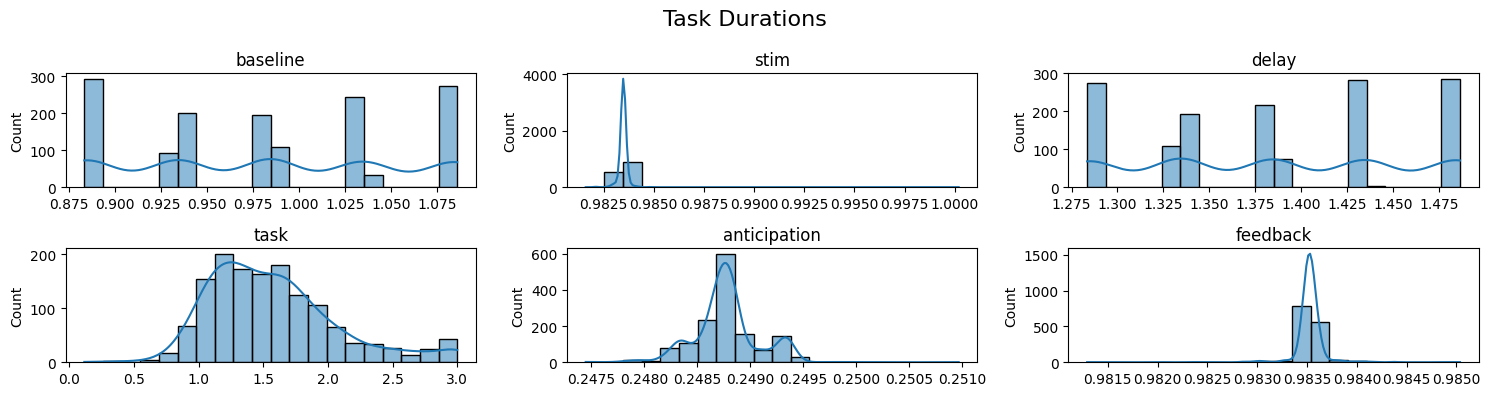

In [28]:
# create column for each phases's duration
expt_phases = ['baseline', 'stim', 'delay', 'task', 'anticipation', 'feedback']
for phase in expt_phases:
    df_subjs[f'{phase}_dur'] = df_subjs[f'{phase}.stopped'] - df_subjs[f'{phase}.started']

# sid, check if these are needed replacements
df_subjs['stim_dur'] = df_subjs['stim.stopped'] - df_subjs['target_stim.started']
df_subjs['feedback_dur'] = df_subjs['feedback.stopped'] - df_subjs['no_resp_text.started']

fig, axs = plt.subplots(2, 3, figsize=(15, 4))
axs, ax = axs.flatten(), 0

for expt_phase in expt_phases:

    sns.histplot(df_subjs[f'{expt_phase}_dur'], bins=20, kde=True, ax=axs[ax])
    axs[ax].set(title=expt_phase, xlabel='', ylabel='Count')
    ax += 1

plt.suptitle(f'Task Durations', fontsize=16)
plt.tight_layout()
plt.show()

### outcome checks and save

In [22]:
df_subjs = df_subjs.sort_values(by=['subj']).reset_index(drop=True)

print(df_subjs['subj'].value_counts(), '\n')
print(df_subjs['outcome'].value_counts(), '\n')
print(df_subjs['correct'].value_counts(), '\n')

df_subjs.to_csv('../../results/psychopy/all_subjs_v2.csv', index=False)

subj
202509.0    240
202511.0    240
202512.0    240
202518.0    240
202521.0    240
202522.0    240
Name: count, dtype: int64 

outcome
 3.0    571
 1.0    560
-3.0    160
-1.0    149
Name: count, dtype: int64 

correct
1.0    1131
0.0     309
Name: count, dtype: int64 

